# Data Demo — Loading the Guitar Make/Model Dataset

This notebook demonstrates loading the guitar make/model dataset
(`stratocaster` / `telecaster`) through the `strat_classifier` package
data module. It imports `make_dataloaders` from `strat_classifier.data` — the
same code path used by training — and shows the class distribution, a training
batch, and sample images.

In [1]:
from collections import Counter
from pathlib import Path

import torch
import matplotlib.pyplot as plt

import strat_classifier
from strat_classifier.data import make_dataloaders, IMAGENET_MEAN, IMAGENET_STD

print("strat_classifier version:", strat_classifier.__version__)
print("torch version:", torch.__version__)

strat_classifier version: 0.1.0
torch version: 2.12.0


## 1. Locate the dataset

Walk up from the working directory to the repo root (the folder containing
`pyproject.toml`), so the notebook works whether Jupyter is launched from the
repo root or from `notebooks/`.

In [2]:
def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data" / "images_labeled"
print("Repo root:", REPO_ROOT)
print("Data dir :", DATA_DIR, "(exists)" if DATA_DIR.exists() else "(MISSING)")

IMG_EXTS = {".jpg", ".jpeg", ".png"}
counts = {
    d.name: len([f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS])
    for d in sorted(DATA_DIR.iterdir()) if d.is_dir()
}
print("Images per class:", counts)

Repo root: /Users/jeremymitaux/Desktop/reverb_project
Data dir : /Users/jeremymitaux/Desktop/reverb_project/data/images_labeled (exists)
Images per class: {'american': 211, 'japanese': 93, 'mexican': 74}


## 2. Build the dataloaders

`make_dataloaders` builds stratified 70/15/15 train/val/test splits, applies
augmenting transforms to train and deterministic transforms to val/test, and
wraps the training set in a `WeightedRandomSampler` to offset class imbalance.
We pass `num_workers=0` to keep things simple inside a notebook.

In [3]:
train_loader, val_loader, test_loader, class_names = make_dataloaders(
    data_dir=DATA_DIR,
    batch_size=32,
    num_workers=0,
)

print("Classes:", class_names)
print(
    f"Train: {len(train_loader.dataset)}  "
    f"Val: {len(val_loader.dataset)}  "
    f"Test: {len(test_loader.dataset)}"
)

Classes: ['american', 'japanese', 'mexican']
Train: 265  Val: 58  Test: 58


## 3. Class distribution

Stratocaster listings outnumber Telecaster (~862 vs ~471 listings) — this
imbalance is exactly why training draws batches with a `WeightedRandomSampler`.

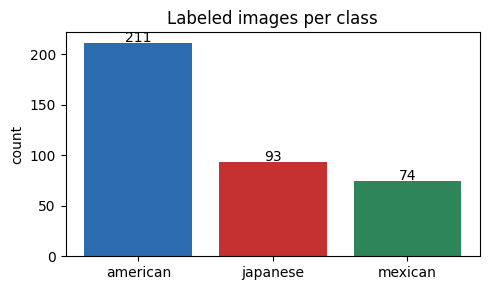

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(counts.keys()), list(counts.values()),
       color=["#2b6cb0", "#c53030"])
ax.set_title("Labeled images per class")
ax.set_ylabel("count")
for i, v in enumerate(counts.values()):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

## 4. Inspect one training batch

Pull a single batch from the training loader and check the tensor shapes,
dtype, value range, and per-class counts.

In [5]:
images, labels = next(iter(train_loader))

print("Batch images tensor:", tuple(images.shape), images.dtype)
print("Batch labels tensor:", tuple(labels.shape), labels.dtype)
print("Pixel value range : [%.2f, %.2f]  (ImageNet-normalized)"
      % (images.min(), images.max()))

batch_dist = Counter(class_names[i] for i in labels.tolist())
print("Label counts in this batch:", dict(batch_dist))

Batch images tensor: (32, 3, 224, 224) torch.float32
Batch labels tensor: (32,) torch.int64
Pixel value range : [-2.12, 2.64]  (ImageNet-normalized)
Label counts in this batch: {'japanese': 10, 'mexican': 12, 'american': 10}


## 5. Visualize sample images

Undo the ImageNet normalization so the images are viewable, then plot a grid
of samples from the batch with their labels.

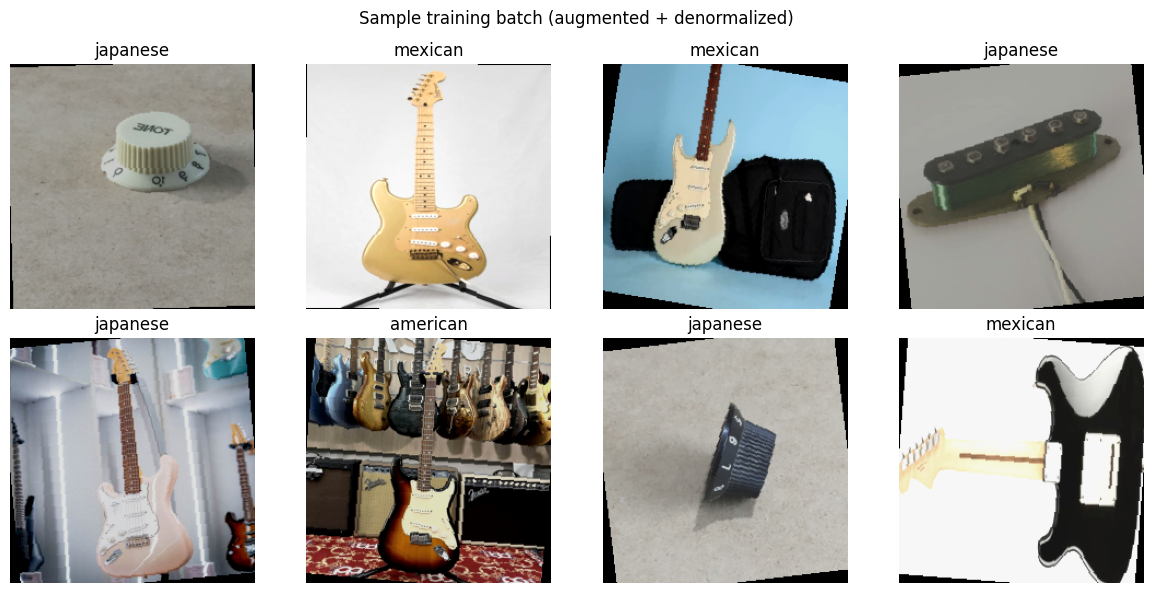

In [6]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(img: torch.Tensor):
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

n = min(8, images.size(0))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, lbl in zip(axes.flat, images[:n], labels[:n]):
    ax.imshow(denormalize(img))
    ax.set_title(class_names[lbl])
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
fig.suptitle("Sample training batch (augmented + denormalized)")
plt.tight_layout()
plt.show()

## Summary

The dataset loads cleanly through `strat_classifier.data.make_dataloaders`:
group-aware (by listing) stratified train/val/test splits, ImageNet-normalized
`224x224` tensors, and a weighted sampler for the imbalanced classes. The same
function is used by `train.py`, so what trains is exactly what is shown here.